/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


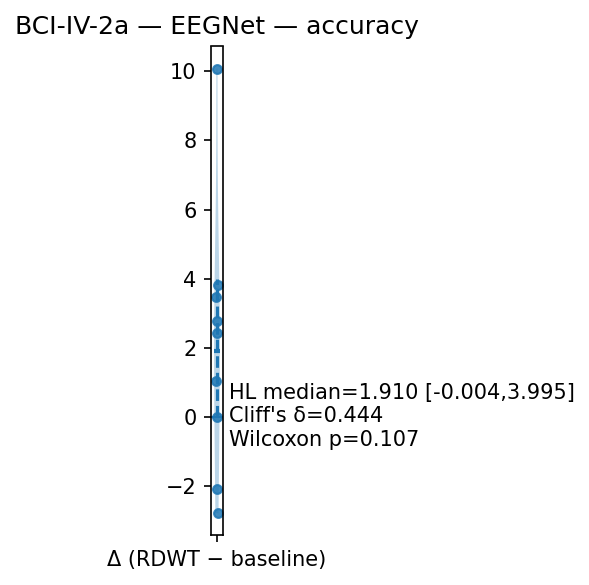

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78154/2039585239.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


Saved: raincloud_delta_accuracy_EEGNet.png


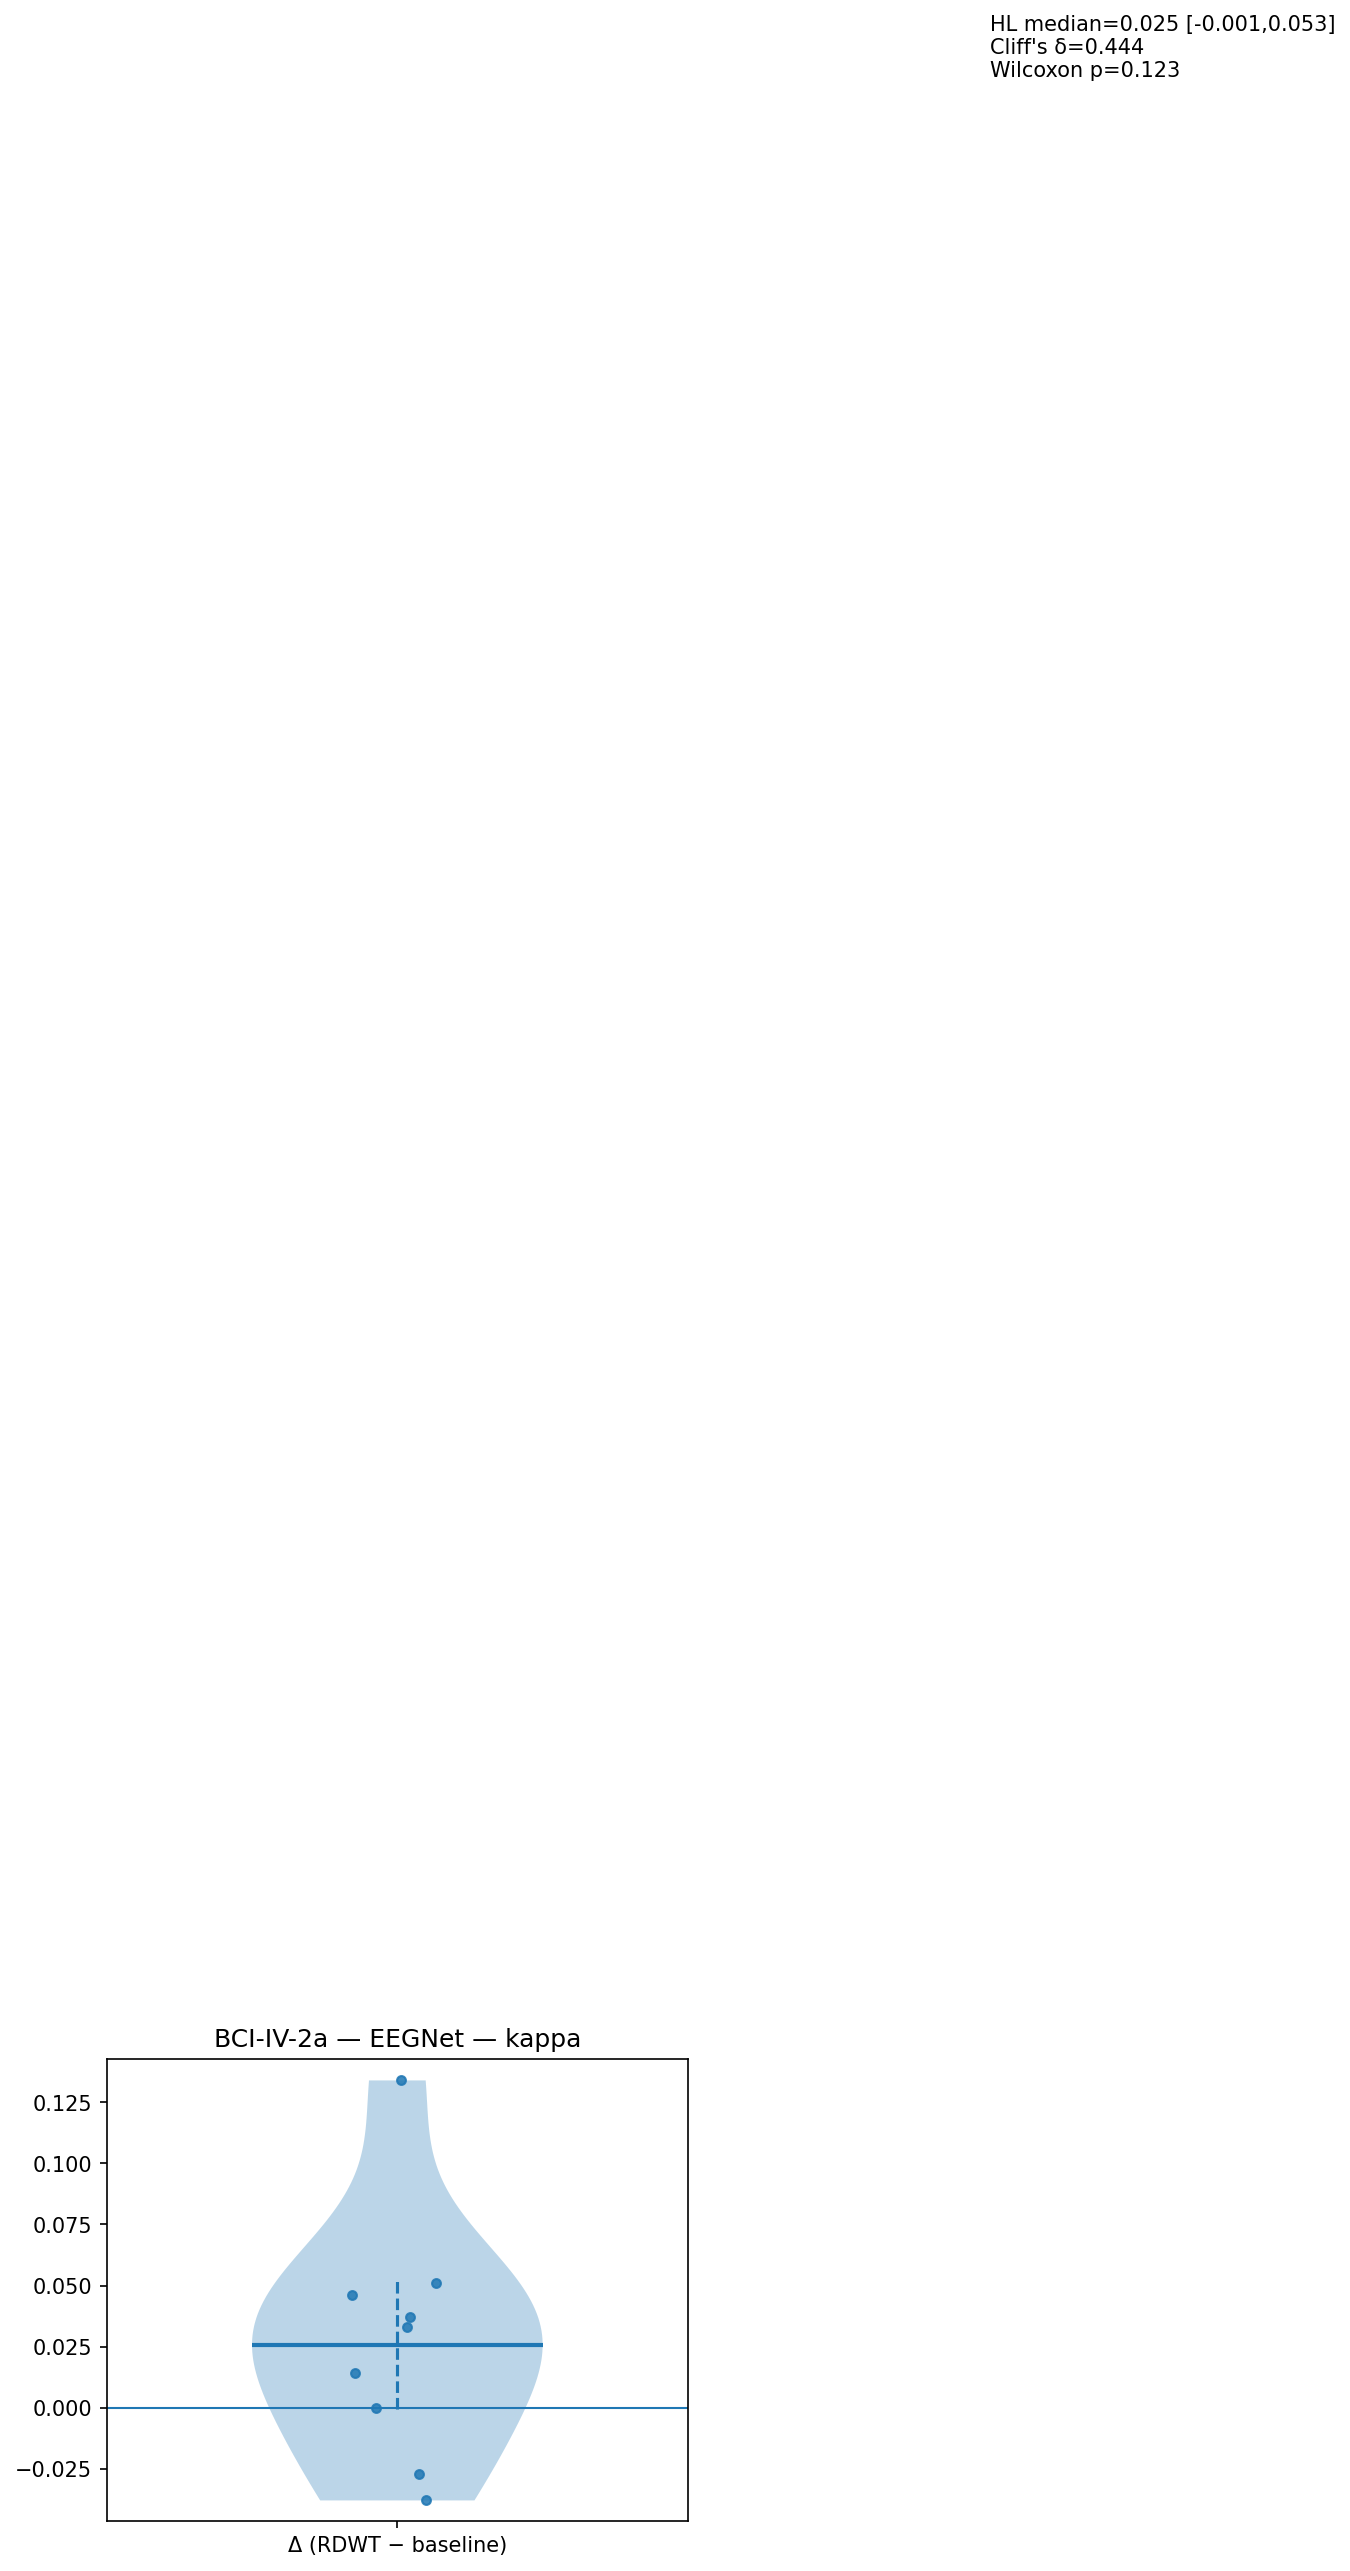

Saved: raincloud_delta_kappa_EEGNet.png


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


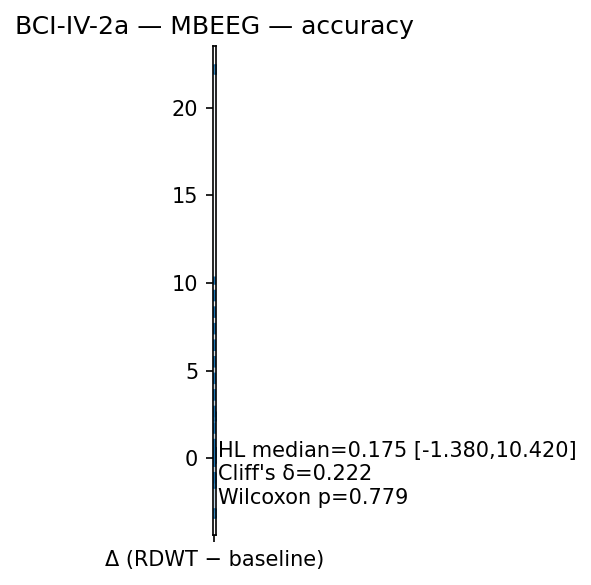

Saved: raincloud_delta_accuracy_MBEEG.png


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:198: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)
/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78154/2039585239.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


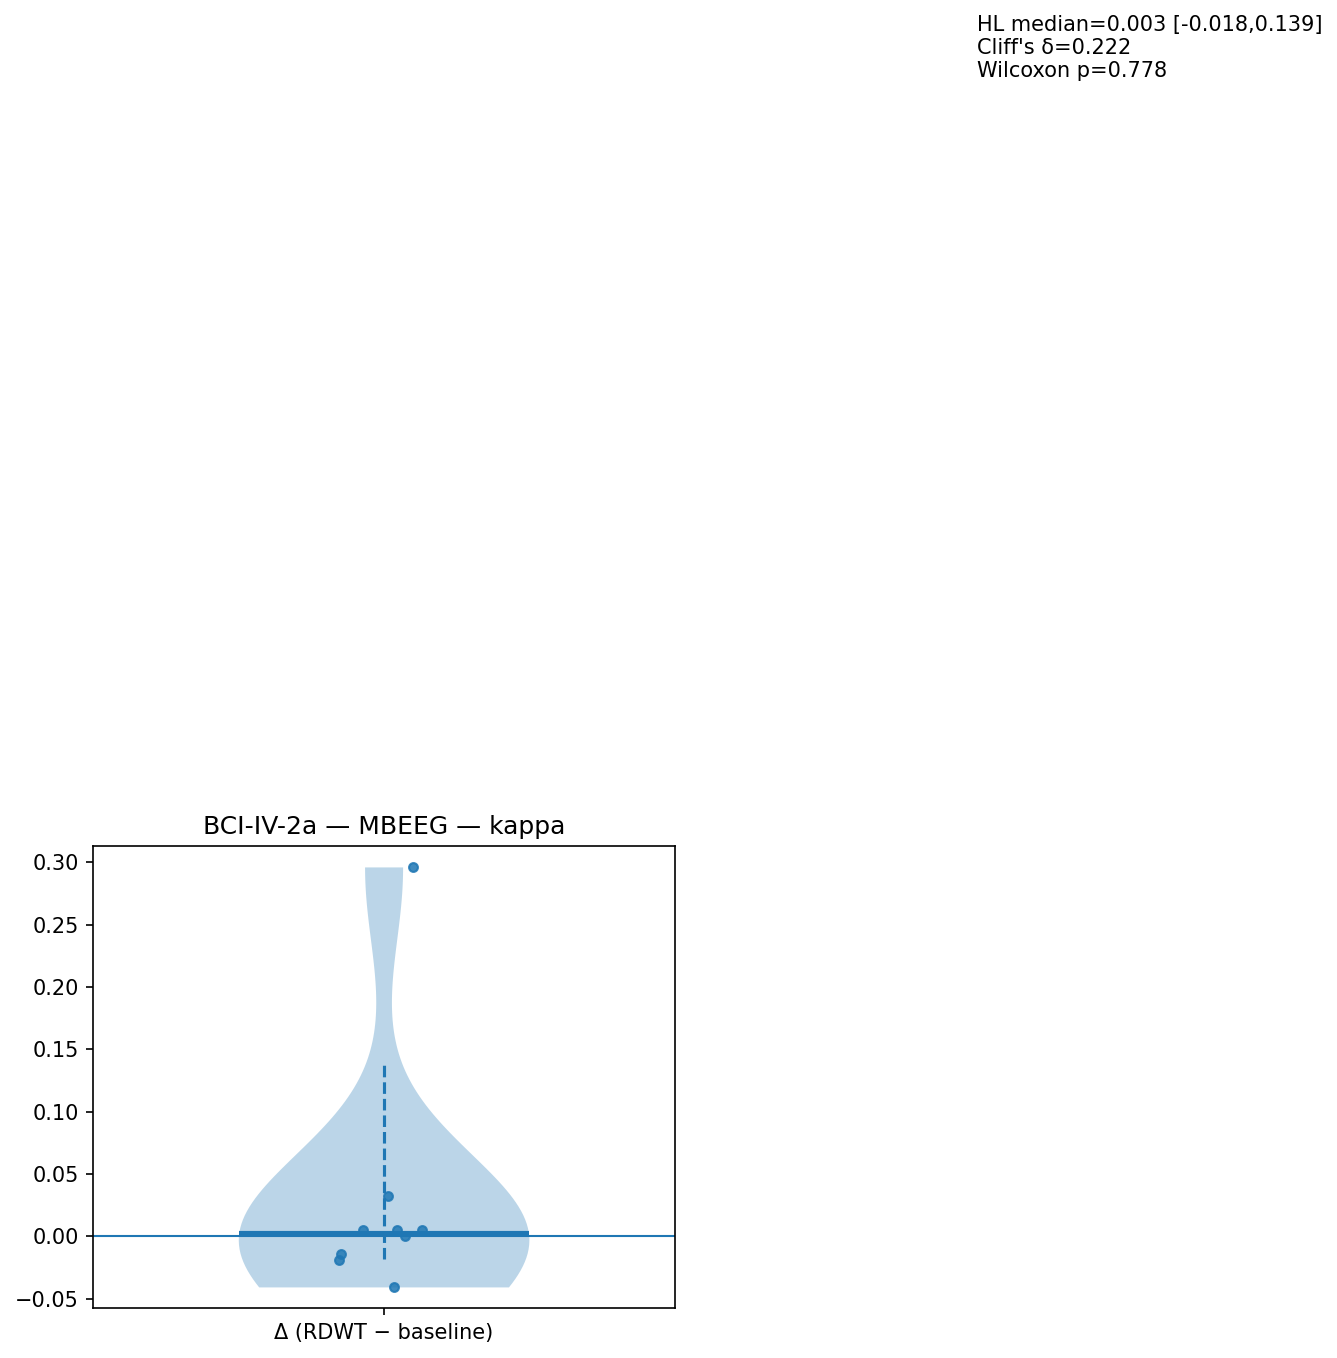

Saved: raincloud_delta_kappa_MBEEG.png


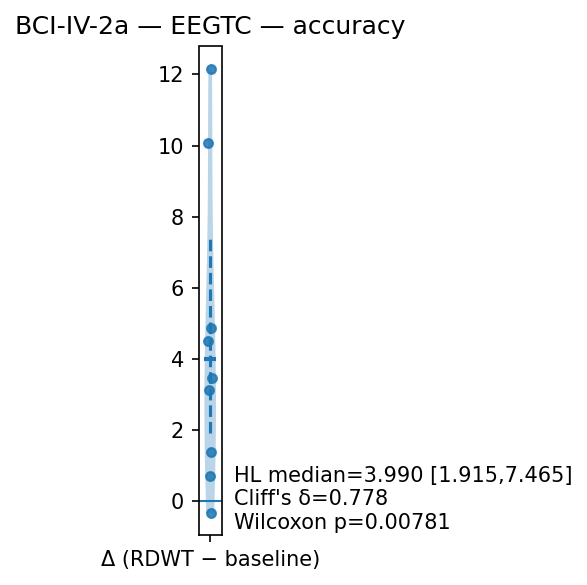

Saved: raincloud_delta_accuracy_EEGTC.png


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78154/2039585239.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


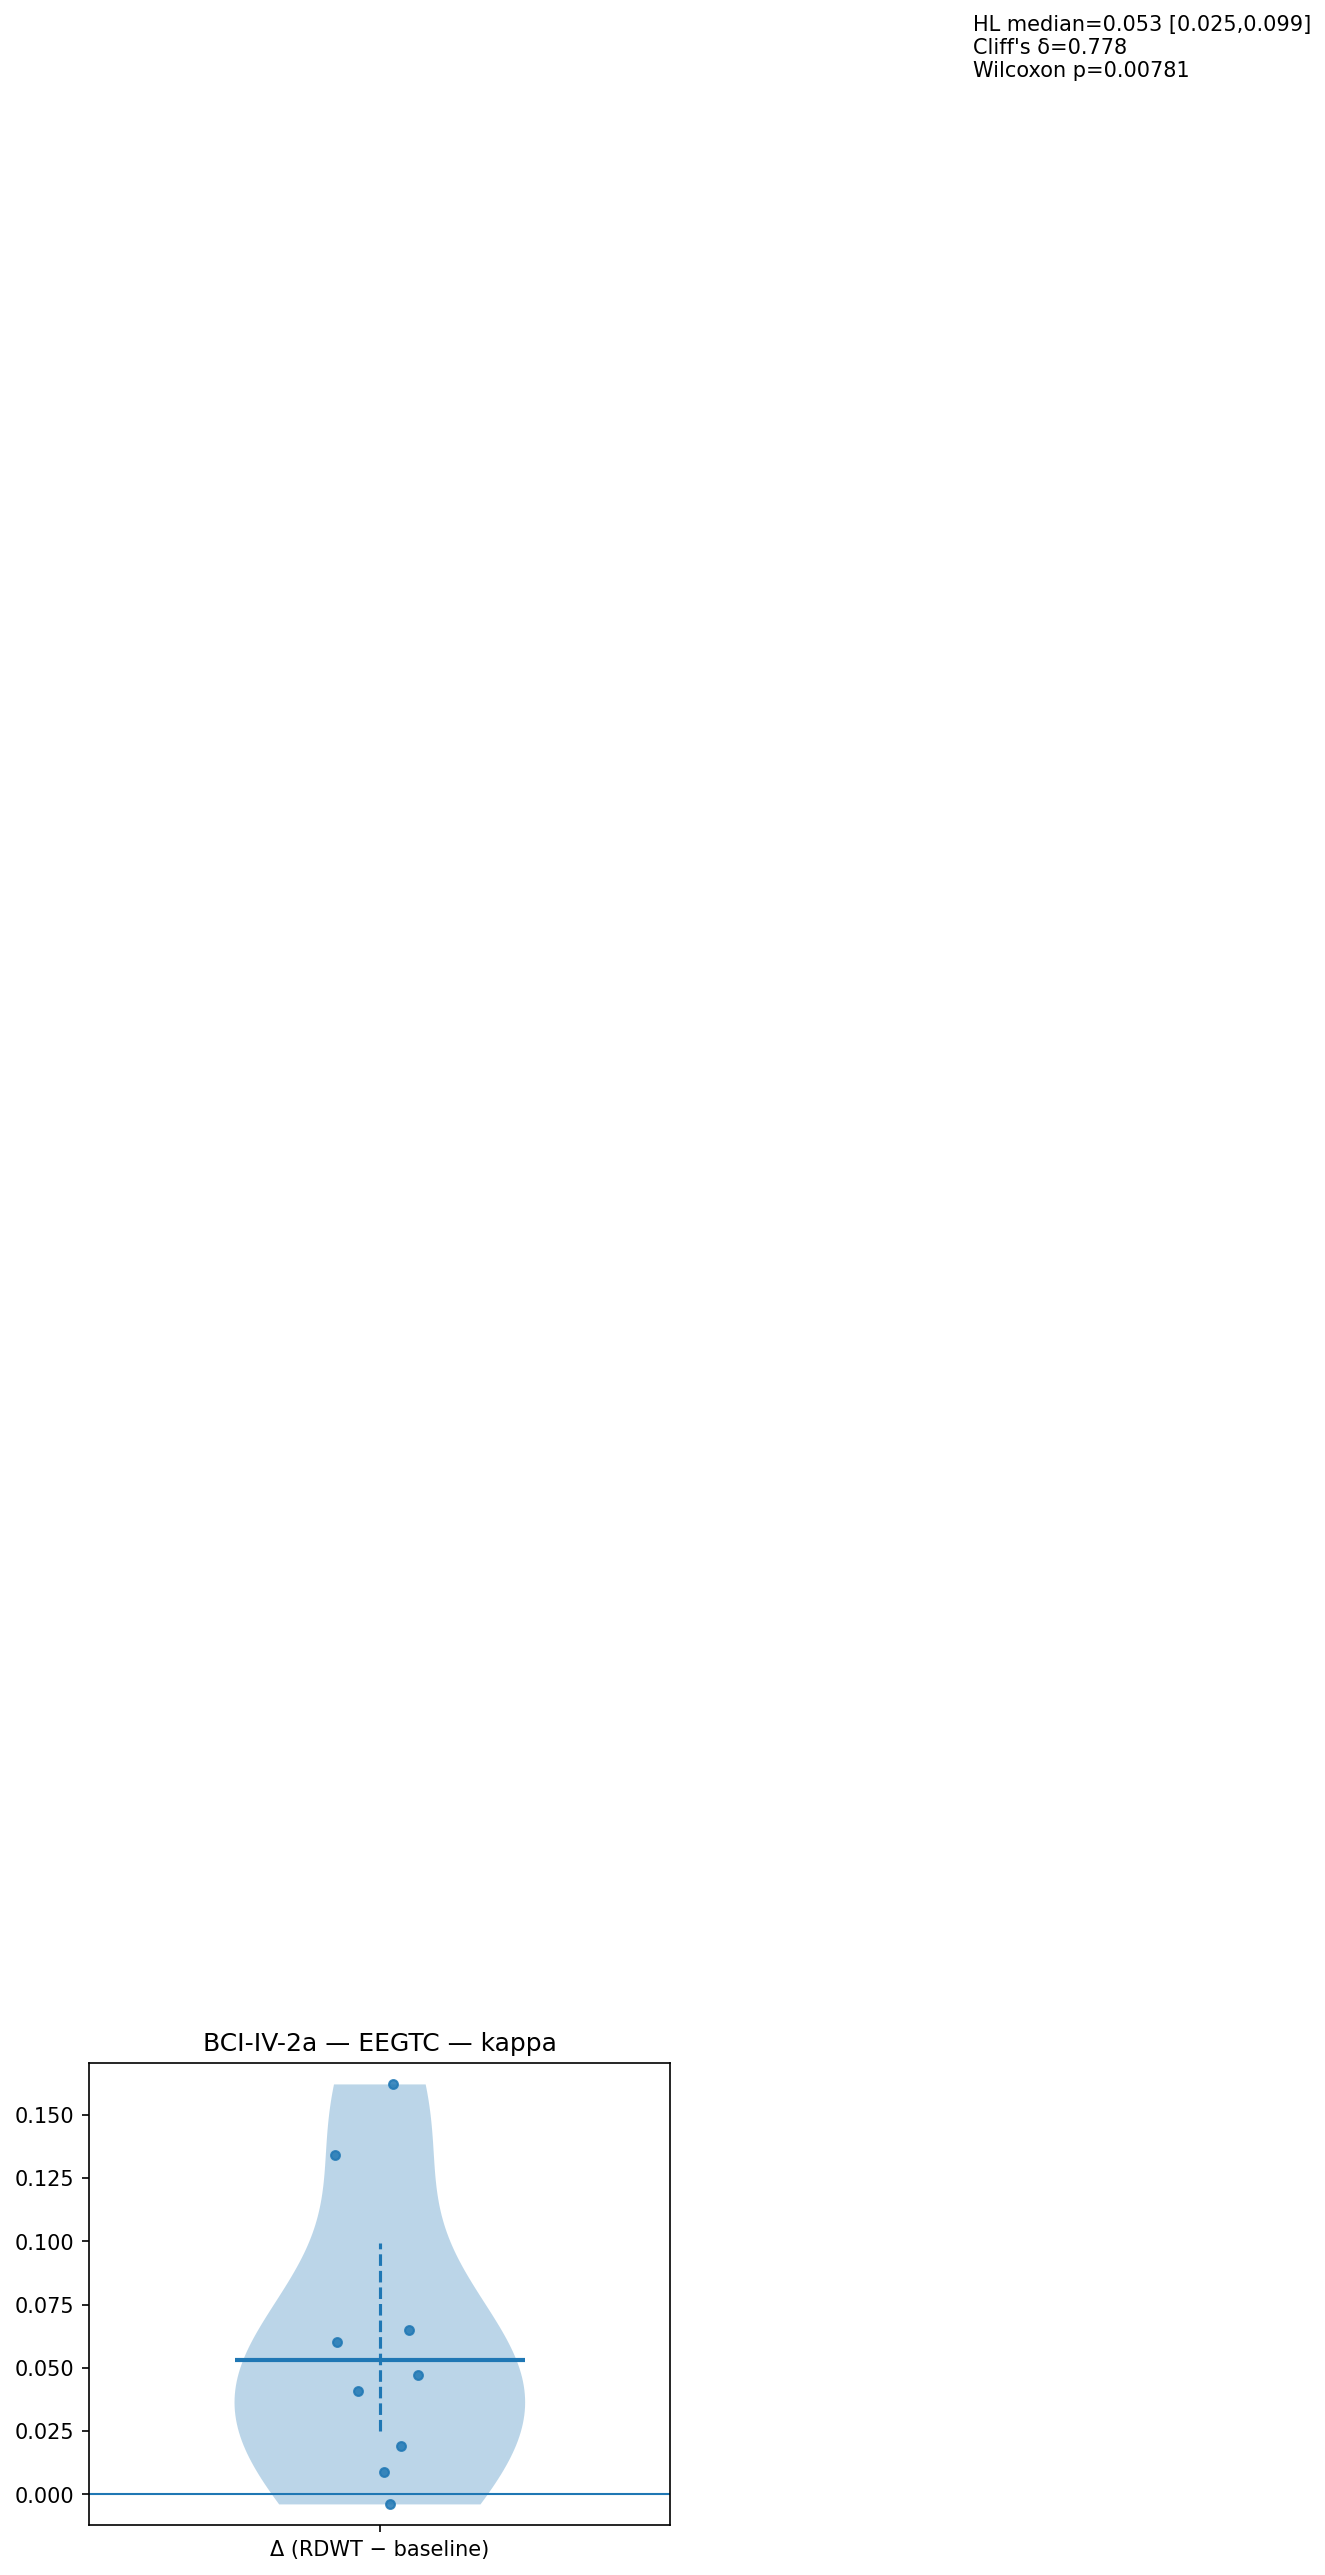

Saved: raincloud_delta_kappa_EEGTC.png


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78154/2039585239.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


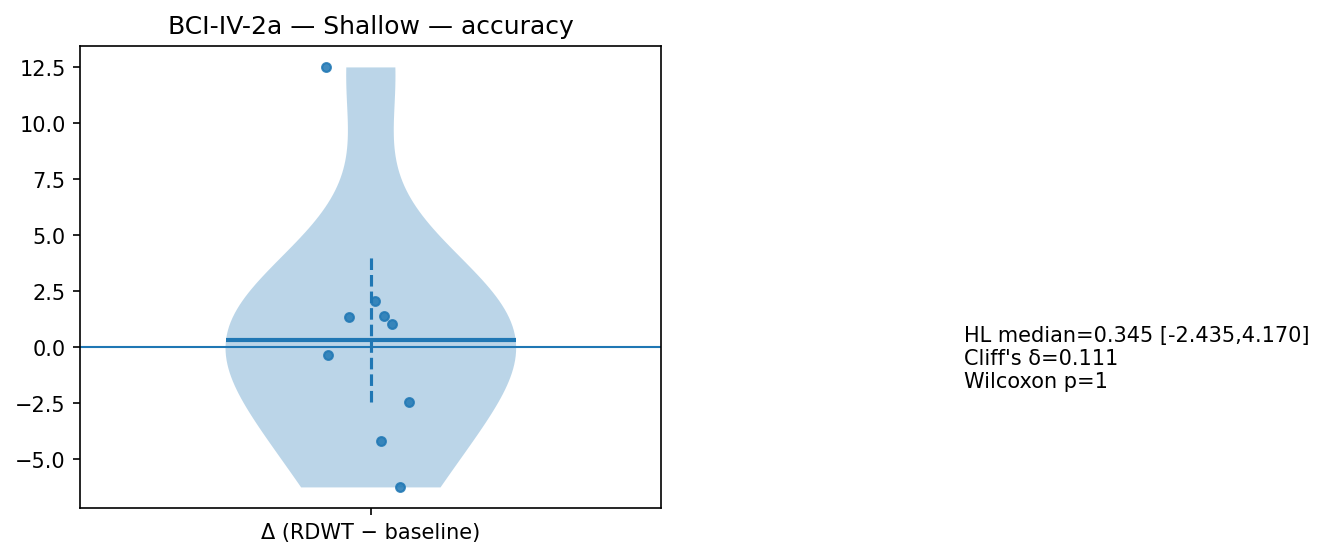

Saved: raincloud_delta_accuracy_Shallow.png


/var/folders/_7/r_r3pscs7s52j4fc3jqjmv3w0000gn/T/ipykernel_78154/2039585239.py:95: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


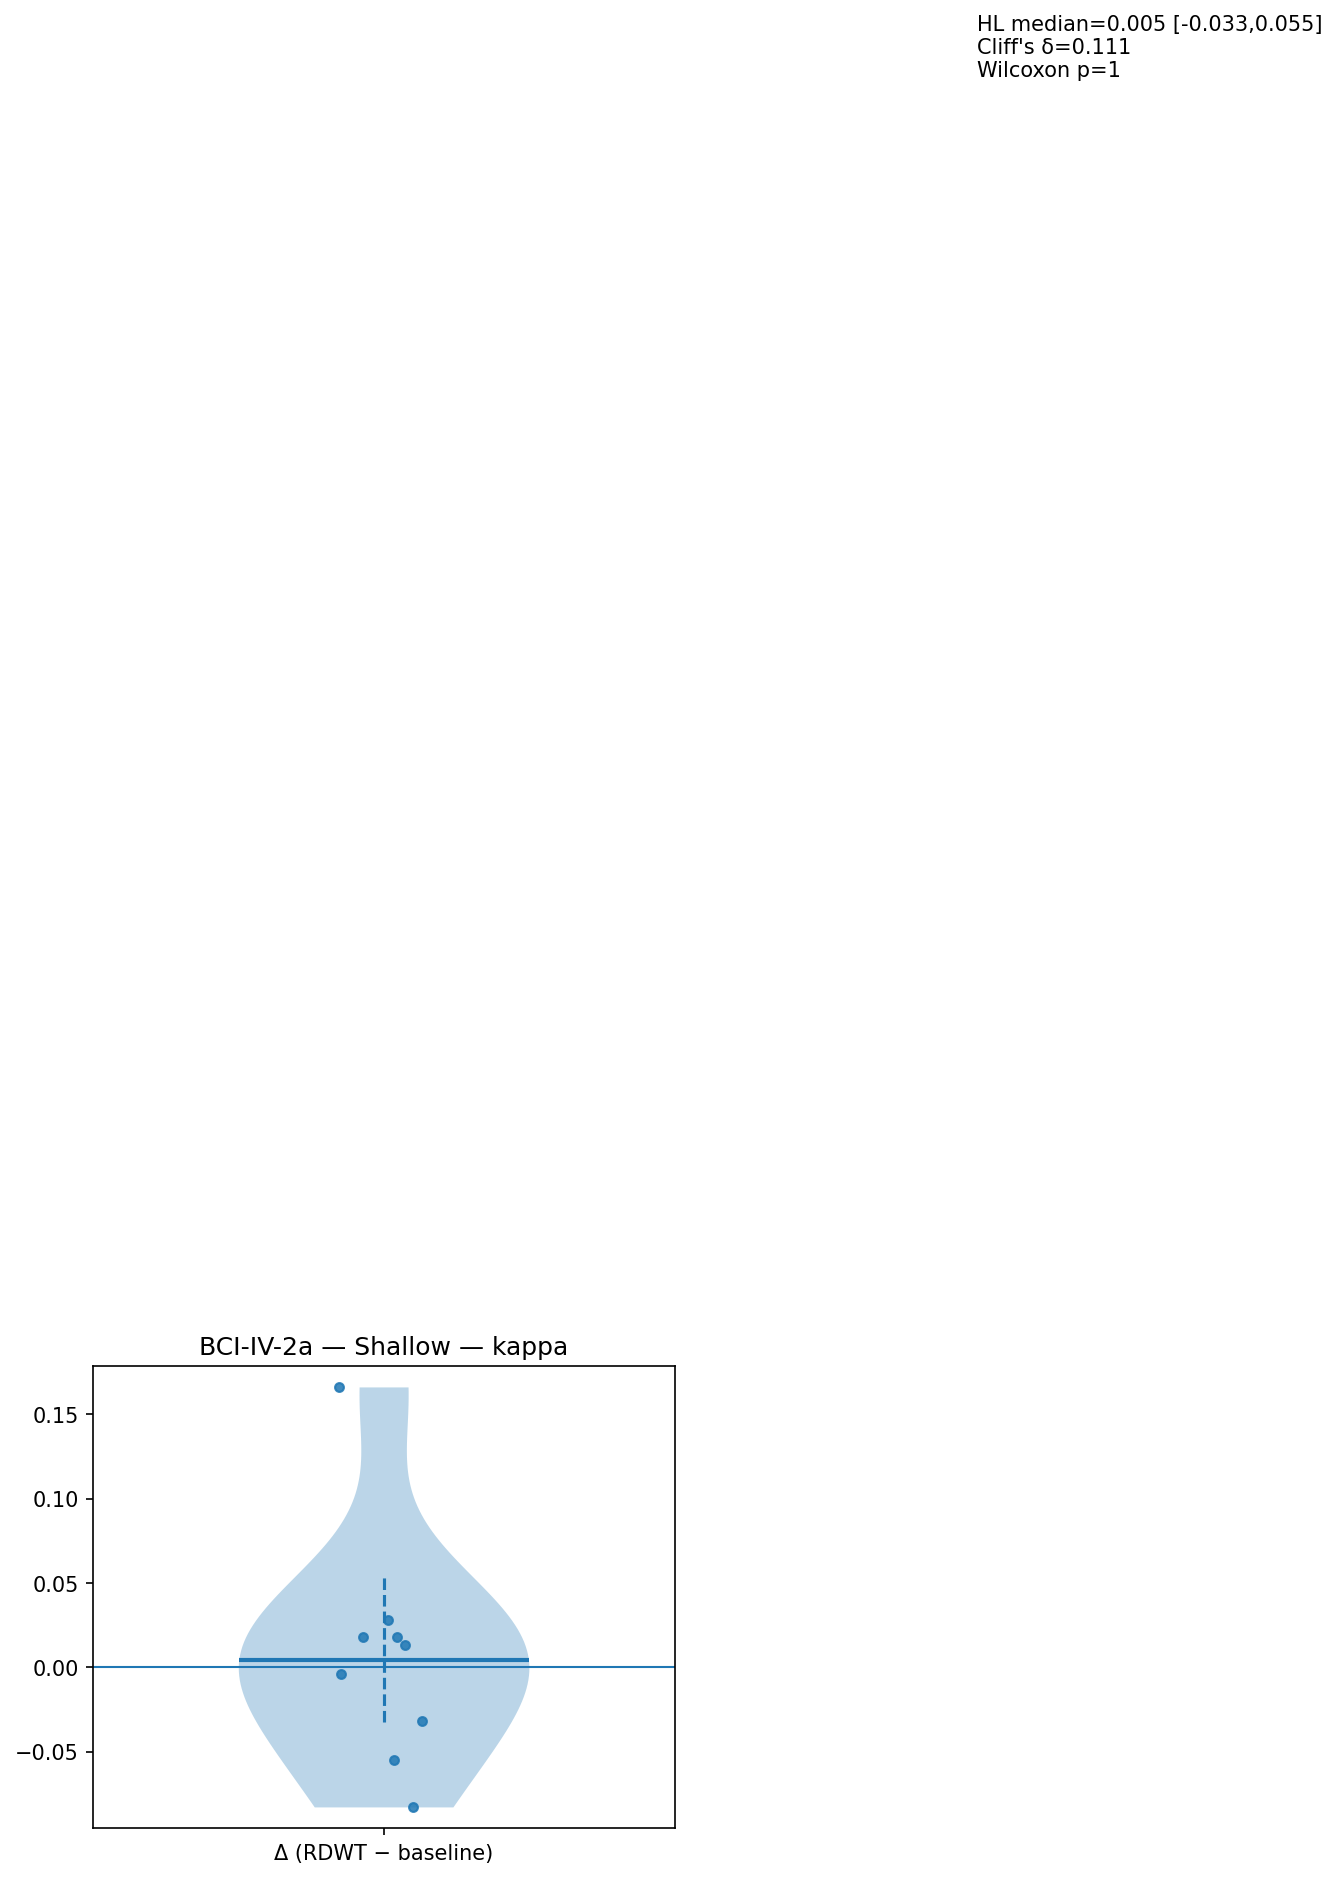

Saved: raincloud_delta_kappa_Shallow.png


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt

# (Opzionale) Wilcoxon; se manca scipy, il codice funziona lo stesso
try:
    from scipy.stats import wilcoxon
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


def hodges_lehmann(x: np.ndarray) -> float:
    """Mediana di Hodges–Lehmann: mediana delle medie a coppie (x_i + x_j)/2."""
    x = np.asarray(x, dtype=float)
    m = (x[:, None] + x[None, :]) / 2.0
    return float(np.median(m))


def bootstrap_ci(x: np.ndarray, stat_fn, n_boot: int = 2000, alpha: float = 0.05, seed: int = 42):
    """IC bootstrap (percentile) per una statistica generica."""
    rng = np.random.default_rng(seed)
    n = len(x)
    boots = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        samp = x[rng.integers(0, n, n)]
        boots[b] = stat_fn(samp)
    lo = np.percentile(boots, 100 * (alpha / 2))
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return float(lo), float(hi)


def cliffs_delta_against_zero(x: np.ndarray) -> float:
    """Cliff's δ contro zero: P(x>0) - P(x<0)."""
    x = np.asarray(x, dtype=float)
    gt = np.sum(x > 0)
    lt = np.sum(x < 0)
    n = len(x)
    return (gt - lt) / n if n > 0 else np.nan


def plot_raincloud_delta(baseline, rdwt, title="BCI-IV-2a — Model — metric", outfile="raincloud.png"):
    """
    Crea un grafico raincloud/violin per i delta per soggetto: (RDWT - baseline).
    - Nessun colore esplicito, solo matplotlib.
    - Un solo grafico per figura (no subplot).
    """
    baseline = np.asarray(baseline, dtype=float)
    rdwt = np.asarray(rdwt, dtype=float)
    if baseline.shape != rdwt.shape:
        raise ValueError("baseline e rdwt devono avere la stessa lunghezza (stessi soggetti).")

    deltas = rdwt - baseline

    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

    # Violin (nessun colore specificato)
    _ = ax.violinplot(deltas, showmeans=False, showextrema=False, showmedians=False)

    # Punti jitter (riproducibile)
    rng = np.random.default_rng(0)
    x0 = 1.0
    jitter = min(max(0.04 * (1 + 10 / len(deltas)), 0.02), 0.08)
    xs = x0 + rng.uniform(-jitter, jitter, size=len(deltas))
    ax.scatter(xs, deltas, s=18, alpha=0.85)

    # Mediana HL + IC 95% (bootstrap)
    hl = hodges_lehmann(deltas)
    lo, hi = bootstrap_ci(deltas, hodges_lehmann, n_boot=2000, alpha=0.05, seed=123)
    ax.hlines([hl], x0 - 0.25, x0 + 0.25, linestyles='solid', linewidth=2)
    ax.vlines([x0], lo, hi, linestyles='dashed', linewidth=1.5)

    # Linea di riferimento a zero
    ax.axhline(0.0, linewidth=1)

    # Assi e titolo
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([x0])
    ax.set_xticklabels(["Δ (RDWT − baseline)"])
    ax.set_title(title)

    # Statistiche a lato
    lines = [f"HL median={hl:.3f} [{lo:.3f},{hi:.3f}]",
             f"Cliff's δ={cliffs_delta_against_zero(deltas):.3f}"]
    if SCIPY_AVAILABLE:
        try:
            wstat, pval = wilcoxon(deltas, alternative='two-sided', zero_method="wilcox")
            lines.append(f"Wilcoxon p={pval:.3g}")
        except Exception:
            pass
    ax.text(1.52, 0.98, "\n".join(lines), transform=ax.get_yaxis_transform(), va='top')

    fig.tight_layout()
    fig.savefig(outfile)
    plt.show()
    plt.close(fig)
    print(f"Saved: {outfile}")


# =========================
# TUTTI I TUOI DATI (BCI-IV-2a)
# =========================
if __name__ == "__main__":
    # ---------- EEGNet ----------
    acc_none = [77.08, 51.74, 91.67, 54.17, 63.89, 45.83, 83.68, 77.08, 67.01]
    acc_rdwt = [79.86, 51.74, 92.71, 57.64, 61.11, 49.65, 86.11, 75.00, 77.08]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2a — EEGNet — accuracy",
                         outfile="raincloud_delta_accuracy_EEGNet.png")

    k_none = [0.694, 0.356, 0.889, 0.389, 0.519, 0.278, 0.782, 0.694, 0.560]
    k_rdwt = [0.731, 0.356, 0.903, 0.435, 0.481, 0.329, 0.815, 0.667, 0.694]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2a — EEGNet — kappa",
                         outfile="raincloud_delta_kappa_EEGNet.png")

    # ---------- MBEEG ----------
    acc_none = [82.29, 53.82, 92.36, 65.62, 44.79, 57.64, 86.46, 79.51, 71.88]
    acc_rdwt = [82.64, 54.17, 91.32, 64.24, 67.01, 57.99, 83.33, 79.51, 74.31]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2a — MBEEG — accuracy",
                         outfile="raincloud_delta_accuracy_MBEEG.png")

    k_none = [0.764, 0.384, 0.898, 0.542, 0.264, 0.435, 0.819, 0.727, 0.625]
    k_rdwt = [0.769, 0.389, 0.884, 0.523, 0.560, 0.440, 0.778, 0.727, 0.657]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2a — MBEEG — kappa",
                         outfile="raincloud_delta_kappa_MBEEG.png")

    # ---------- EEGTC ----------
    acc_none = [63.19, 49.65, 81.25, 50.69, 62.50, 46.18, 80.90, 68.75, 76.04]
    acc_rdwt = [75.35, 52.78, 85.76, 60.76, 67.36, 49.65, 80.56, 70.14, 76.74]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2a — EEGTC — accuracy",
                         outfile="raincloud_delta_accuracy_EEGTC.png")

    k_none = [0.509, 0.329, 0.750, 0.343, 0.500, 0.282, 0.745, 0.583, 0.681]
    k_rdwt = [0.671, 0.370, 0.810, 0.477, 0.565, 0.329, 0.741, 0.602, 0.690]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2a — EEGTC — kappa",
                         outfile="raincloud_delta_kappa_EEGTC.png")

    # ---------- Shallow ----------
    acc_none = [72.92, 46.88, 83.68, 47.92, 63.19, 40.97, 81.94, 78.82, 75.35]
    acc_rdwt = [74.31, 48.26, 83.33, 60.42, 56.94, 38.54, 77.78, 79.86, 77.43]
    plot_raincloud_delta(acc_none, acc_rdwt,
                         title="BCI-IV-2a — Shallow — accuracy",
                         outfile="raincloud_delta_accuracy_Shallow.png")

    k_none = [0.639, 0.292, 0.782, 0.306, 0.509, 0.213, 0.759, 0.718, 0.671]
    k_rdwt = [0.657, 0.310, 0.778, 0.472, 0.426, 0.181, 0.704, 0.731, 0.699]
    plot_raincloud_delta(k_none, k_rdwt,
                         title="BCI-IV-2a — Shallow — kappa",
                         outfile="raincloud_delta_kappa_Shallow.png")
